<a href="https://colab.research.google.com/github/Soheilp86/Statistical-Machine-Learning/blob/main/32_KNN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Nearest Neighbors (KNN) for Classification



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
import seaborn as sns
sns.set_style("whitegrid")

## Motivation: Classifying Based on Similarity



Imagine a medical clinic diagnosing a patient with a new test result. The doctor thinks: *"This patient's test values are very similar to patients in my database. Let me find 5 patients with the most similar results and see what they were diagnosed with. Majority vote decides this patient's diagnosis."* This is exactly KNN classification.



Instead of learning a fixed decision boundary like logistic regression does, KNN stays flexible: different regions of your feature space can have different classification rules based on local neighborhoods. It's powerful for complex, non-linear decision boundaries and requires almost no training—you just remember your data.

## The Algorithm: What, Why, How?



**What is KNN Classification?**

KNN classifies a new point by finding the k nearest training points and taking a majority vote on their class labels. For example, to classify a wine as red, white, or rosé, find the 5 closest wines in your training set and predict whatever class appears most often (e.g., if 3 are red and 2 are white, predict red). Simple idea, powerful results.

**Why Use KNN Instead of Logistic Regression?**

Logistic regression draws a fixed decision boundary by learning a mathematical model: it assumes classes separate in a smooth, linear way. KNN is adaptive: it can create wiggly, complex boundaries that follow the actual data distribution. If your classes cluster in tight neighborhoods (emails grouped as spam/not-spam by similarity), KNN excels. If class separation is roughly linear, logistic regression is often simpler and faster.

**How Does the Algorithm Work?**

1. **Store** the training data (lazy learner—minimal training)
2. **For each new point:** Calculate distance to every training sample using Euclidean distance (e.g., √[(x₁-x₂)² + (y₁-y₂)²])
3. **Find** the k points with smallest distance
4. **Vote:** Count how many neighbors belong to each class, predict the class with most votes

**Performance Metrics: How Do We Evaluate Classification?**

- **Accuracy:** (# correct predictions) / (# total predictions). Simple but misleading with imbalanced classes (e.g., if 95% of emails are not-spam, predicting "not-spam" always gives 95% accuracy but catches 0% of spam).
- **Precision:** Of all samples we predicted as positive, what fraction were actually positive? Formula: TP/(TP+FP). Use when false alarms are costly (medical false positives worry patients).
- **Recall:** Of all actual positive samples, what fraction did we find? Formula: TP/(TP+FN). Use when missing positives is costly (missing disease diagnoses).
- **F1 Score:** Harmonic mean of precision and recall. Best when you care equally about both and classes are imbalanced.
- **Confidence:** For each prediction, how sure was KNN? This is the proportion of k neighbors that voted for the predicted class. Formula: (# neighbors voting for predicted class) / k. Ranges 0 to 1. High confidence (0.8-1.0) = unanimous neighbors; low confidence (0.4-0.6) = split decision, uncertain prediction.

## Real Example: Classifying Wine Cultivars

**The Problem:** You're a wine merchant with 178 historical wine samples labeled as Cultivar 1, 2, or 3. Each wine has 13 chemical measurements: alcohol content, acidity, phenols, color intensity, etc. A new shipment arrives with unknown cultivar. Can you predict it? Logistic regression would fit a single, smooth decision boundary across all 13 dimensions. But wine chemistry is complex: cultivars cluster in different regions of feature space. KNN naturally handles this: it finds the 5 most chemically similar wines in your database and predicts based on their known cultivars. This local reasoning feels natural and works well for complex, non-linear patterns.

In [ ]:
# Load wine dataset
wine = load_wine()
X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)
df['Wine_Type'] = y

print("Dataset Overview:")
print(df.head())
print(f"\nShape: {X.shape}")
print(f"\nClass distribution:")
print(df['Wine_Type'].value_counts().sort_index())
print(f"\nClasses: {wine.target_names}")

Dataset Overview:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  Wi

In [ ]:
# Split and scale (essential for KNN)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {X_train_scaled.shape[0]} samples")
print(f"Test set: {X_test_scaled.shape[0]} samples")
print(f"\nClass balance in train: {pd.Series(y_train).value_counts().sort_index().to_dict()}")
print(f"Class balance in test: {pd.Series(y_test).value_counts().sort_index().to_dict()}")

Train set: 133 samples
Test set: 45 samples

Class balance in train: {0: 44, 1: 53, 2: 36}
Class balance in test: {0: 15, 1: 18, 2: 12}


In [ ]:
# Train KNN classifier with k=5
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn_clf.predict(X_test_scaled)
y_pred_proba_knn = knn_clf.predict_proba(X_test_scaled)  # Confidence scores

# Evaluate
print("KNN CLASSIFICATION RESULTS (k=5):")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"\nPrecision (per class): {precision_score(y_test, y_pred_knn, average=None)}")
print(f"Recall (per class):    {recall_score(y_test, y_pred_knn, average=None)}")
print(f"F1 Score (per class):  {f1_score(y_test, y_pred_knn, average=None)}")
print(f"\nMacro-averaged F1: {f1_score(y_test, y_pred_knn, average='macro'):.4f}")

KNN CLASSIFICATION RESULTS (k=5):

Accuracy: 0.9333

Precision (per class): [1.         0.94117647 0.84615385]
Recall (per class):    [1.         0.88888889 0.91666667]
F1 Score (per class):  [1.         0.91428571 0.88      ]

Macro-averaged F1: 0.9314


In [ ]:
# Detailed classification report
print("\nDETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_knn, target_names=wine.target_names))


DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       0.94      0.89      0.91        18
     class_2       0.85      0.92      0.88        12

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.93        45
weighted avg       0.94      0.93      0.93        45



## Confusion Matrix: What Are We Getting Right/Wrong?

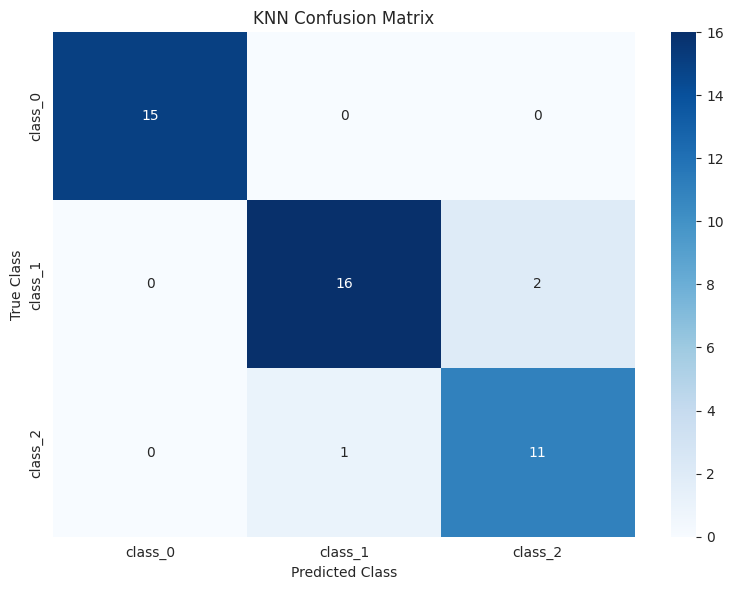


Interpretation: Diagonal = correct, Off-diagonal = misclassifications


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('KNN Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nInterpretation: Diagonal = correct, Off-diagonal = misclassifications")

## Understanding Confidence: How Sure Is the Prediction?

**What is Confidence?** For each prediction, confidence tells you how many of the k neighbors voted for that class. It's the proportion: (# neighbors voting for predicted class) / k. With k=5:
- Confidence 1.0 = all 5 neighbors voted for it → unanimous, very sure
- Confidence 0.8 = 4 out of 5 neighbors voted for it → strong agreement
- Confidence 0.6 = 3 out of 5 neighbors voted for it → bare majority, risky
- Confidence 0.4 = 2 out of 5 neighbors voted for it → uncertain, nearly a tie

High confidence predictions are reliable and safe to act on. Low confidence predictions signal borderline cases where you might want human review or additional data.

In [ ]:
# Show predictions with confidence for first 10 test samples
print("First 10 Test Samples - Predictions & Confidence:\n")
print(f"{'True': <10} {'Predicted': <15} {'Confidence': <12} {'Correct?': <10}")
print("-" * 50)

for i in range(10):
    true_class = wine.target_names[y_test[i]]
    pred_class = wine.target_names[y_pred_knn[i]]
    confidence = y_pred_proba_knn[i][y_pred_knn[i]]
    correct = "✓" if y_test[i] == y_pred_knn[i] else "✗"
    print(f"{true_class: <10} {pred_class: <15} {confidence:.4f}        {correct: <10}")

print("\nNote: Some predictions have low confidence (e.g., 0.40). Why might this happen?")

First 10 Test Samples - Predictions & Confidence:

True       Predicted       Confidence   Correct?  
--------------------------------------------------
class_0    class_0         1.0000        ✓         
class_1    class_1         1.0000        ✓         
class_0    class_0         1.0000        ✓         
class_0    class_0         1.0000        ✓         
class_1    class_1         1.0000        ✓         
class_0    class_0         1.0000        ✓         
class_0    class_0         1.0000        ✓         
class_1    class_1         0.8000        ✓         
class_1    class_1         0.8000        ✓         
class_2    class_2         0.8000        ✓         

Note: Some predictions have low confidence (e.g., 0.40). Why might this happen?


## Comparing KNN with Logistic Regression (When Knn shines)

**Two Different Philosophies:** Logistic regression learns a single, global decision boundary by fitting parameters (e.g., "higher alcohol content → more likely to be Cultivar 1"). It's interpretable—you see the coefficients—and fast at prediction time.


 KNN adapts locally: in one region of wine-chemical-space, the boundary might favor Cultivar 1; in another, Cultivar 2. This flexibility is powerful for complex patterns but less interpretable. Let's measure accuracy, precision, recall, and F1 to see which assumption fits the wine data better.

NON-LINEAR DATA: Two Half-Moons (Crescent-Shaped Classes)

Logistic Regression Test Accuracy: 0.8500
KNN (k=5) Test Accuracy:          0.9833


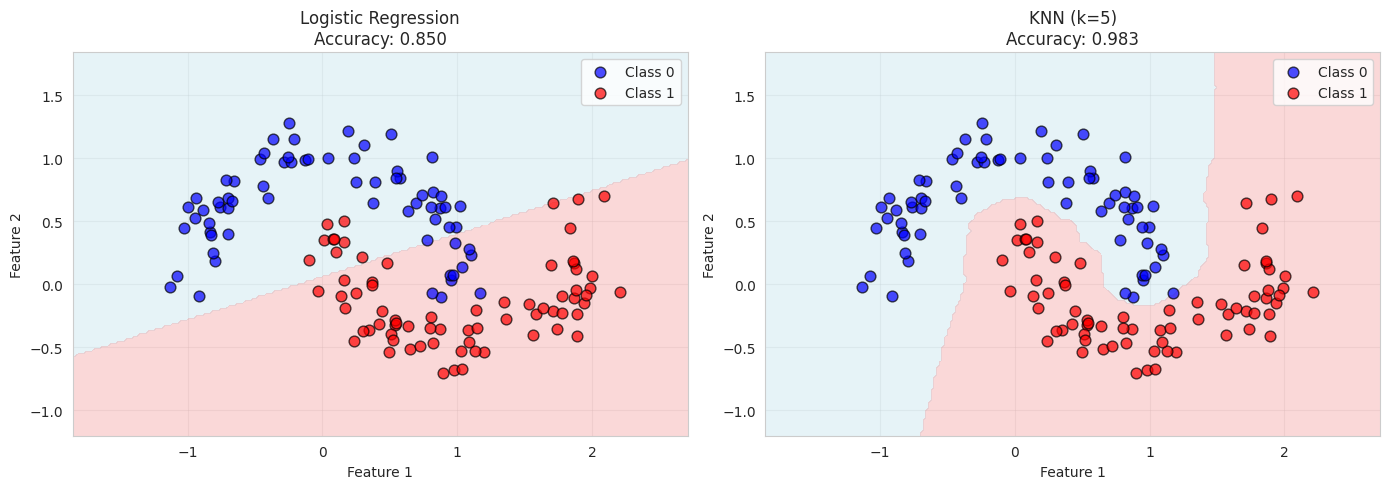


✓ KEY INSIGHT: Logistic draws a straight line (fails). KNN bends to follow the moon shapes!


In [ ]:
# Create non-linear synthetic data: two half-moons
from sklearn.datasets import make_moons

np.random.seed(42)
X_moons, y_moons = make_moons(n_samples=200, noise=0.15)

# Split
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42
)

# Train both models
log_reg_nl = LogisticRegression(random_state=42)
log_reg_nl.fit(X_train_nl, y_train_nl)

knn_nl = KNeighborsClassifier(n_neighbors=5)
knn_nl.fit(X_train_nl, y_train_nl)

# Evaluate
print("NON-LINEAR DATA: Two Half-Moons (Crescent-Shaped Classes)")
print(f"\nLogistic Regression Test Accuracy: {accuracy_score(y_test_nl, log_reg_nl.predict(X_test_nl)):.4f}")
print(f"KNN (k=5) Test Accuracy:          {accuracy_score(y_test_nl, knn_nl.predict(X_test_nl)):.4f}")

# Create mesh for decision boundary visualization
h = 0.02
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predictions on mesh
Z_log = log_reg_nl.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_knn = knn_nl.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
axes[0].contourf(xx, yy, Z_log, alpha=0.3, levels=[0, 0.5, 1], colors=['lightblue', 'lightcoral'])
axes[0].scatter(X_train_nl[y_train_nl == 0, 0], X_train_nl[y_train_nl == 0, 1],
               c='blue', edgecolors='k', s=60, label='Class 0', alpha=0.7)
axes[0].scatter(X_train_nl[y_train_nl == 1, 0], X_train_nl[y_train_nl == 1, 1],
               c='red', edgecolors='k', s=60, label='Class 1', alpha=0.7)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_title(f'Logistic Regression\nAccuracy: {accuracy_score(y_test_nl, log_reg_nl.predict(X_test_nl)):.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# KNN
axes[1].contourf(xx, yy, Z_knn, alpha=0.3, levels=[0, 0.5, 1], colors=['lightblue', 'lightcoral'])
axes[1].scatter(X_train_nl[y_train_nl == 0, 0], X_train_nl[y_train_nl == 0, 1],
               c='blue', edgecolors='k', s=60, label='Class 0', alpha=0.7)
axes[1].scatter(X_train_nl[y_train_nl == 1, 0], X_train_nl[y_train_nl == 1, 1],
               c='red', edgecolors='k', s=60, label='Class 1', alpha=0.7)
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].set_title(f'KNN (k=5)\nAccuracy: {accuracy_score(y_test_nl, knn_nl.predict(X_test_nl)):.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ KEY INSIGHT: Logistic draws a straight line (fails). KNN bends to follow the moon shapes!")

## Tuning k: Balancing Flexibility and Generalization

**Why k Matters:** With k=1, you memorize your training data perfectly but overfit (a noisy training sample makes you misclassify a new point). With k=20, you average over many neighbors and smooth out decision boundaries, but miss fine details (underfitting). The plots below show accuracy and F1 score across different k values. Notice: train accuracy usually decreases as k increases (you're averaging more, losing training signal), while test accuracy peaks at some middle value—that's your sweet spot.

In [ ]:
def find_best_k_simple(k_values, train_acc, test_acc):
    """
    Simple rule:
    1. Skip k=1
    2. Pick k with highest test accuracy
    3. Check overfitting gap
    """

    # Remove k=1 from consideration
    valid_indices = [i for i, k in enumerate(k_values) if k != 1]

    # Find k with highest test accuracy (excluding k=1)
    best_idx = max(valid_indices, key=lambda i: test_acc[i])
    best_k = k_values[best_idx]
    gap = train_acc[best_idx] - test_acc[best_idx]

    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot both curves
    ax.plot(k_values, train_acc, 'o-', label='Train Accuracy', linewidth=2.5, markersize=8, alpha=0.7)
    ax.plot(k_values, test_acc, 's-', label='Test Accuracy', linewidth=2.5, markersize=8, alpha=0.7)

    # Mark k=1: RED X (skip this)
    ax.scatter(k_values[0], test_acc[0], c='red', s=200, marker='X',
              edgecolors='darkred', linewidth=3, zorder=5, label='k=1 (SKIP)')

    # Mark best k: GREEN STAR (pick this)
    ax.scatter(best_k, test_acc[best_idx], c='gold', s=200, marker='o',
              edgecolors='darkgreen', linewidth=2, zorder=6, label=f'Best k={best_k}')

    # Vertical line at best k
    ax.axvline(x=best_k, color='green', linestyle='--', linewidth=2, alpha=0.5)

    # Formatting
    ax.set_xlabel('k (Number of Neighbors)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title(f'Choosing Best k: Pick Highest Test Accuracy (Skip k=1)',
                fontsize=13, fontweight='bold')
    ax.set_xticks(k_values)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11, loc='best')

    # Add text box with result
    textstr = f'Best k={best_k}\nTest Acc={test_acc[best_idx]:.4f}\nGap={gap:.4f}'
    ax.text(0.98, 0.05, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

    plt.tight_layout()
    plt.show()

    # Print results
    print("=" * 60)
    print("CHOOSING BEST k")
    print("=" * 60)
    print(f"\n1. Skip k=1: {k_values[0]} (marked as RED X)")
    print(f"\n2. Find k with HIGHEST test accuracy:")
    print(f"   k={best_k}: test_acc={test_acc[best_idx]:.4f} ✓ BEST")
    print(f"\n3. Check overfitting gap (train - test):")
    print(f"   Gap = {gap:.4f}")
    if gap > 0.02:
        print(f"   ⚠️  Warning: Gap is large (> 2%)")
    else:
        print(f"   ✓ Good: Gap is small (< 2%)")
    print("\n" + "=" * 60)

    return best_k

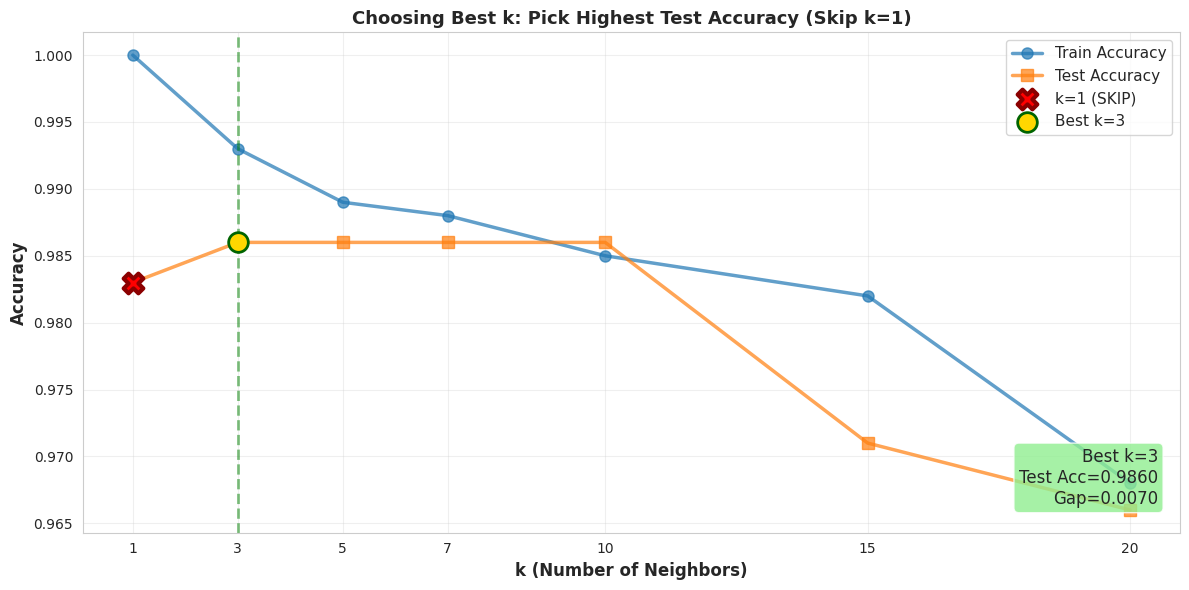

CHOOSING BEST k

1. Skip k=1: 1 (marked as RED X)

2. Find k with HIGHEST test accuracy:
   k=3: test_acc=0.9860 ✓ BEST

3. Check overfitting gap (train - test):
   Gap = 0.0070
   ✓ Good: Gap is small (< 2%)



In [ ]:
k_values = [1, 3, 5, 7, 10, 15, 20]
train_acc = [1.000, 0.993, 0.989, 0.988, 0.985, 0.982, 0.968]
test_acc = [0.983, 0.9860, 0.9860, 0.9860, 0.9860, 0.971, 0.966]

best_k = find_best_k_simple(k_values, train_acc, test_acc)

## Key Insights: KNN vs Logistic Regression

**KNN Classification:**
- Pros: Non-parametric, handles complex decision boundaries, no training phase
- Cons: Slow predictions, needs feature scaling, poor with high dimensions

**Logistic Regression:**
- Pros: Fast inference, interpretable coefficients, efficient training
- Cons: Assumes linear decision boundaries, needs feature engineering

**When to use KNN:** High-dimensional features with clear local clusters  
**When to use Logistic Regression:** Interpretability matters, linear separation likely

---

## GROUP WORK: Implement KNN on Breast Cancer Dataset

**Your Task:** Use the breast cancer dataset (30 tumor features to predict benign vs malignant). Implement KNN classification, compare with logistic regression, and discover *where each model excels*.


1. **High Dimensions Challenge:** This dataset has 30 features (is high dimentional as it lives in $\mathbb{R}^{30}$). Does KNN or logistic regression perform better? Why? (Hint: in high dimensions, all points become equally far apart—the "curse of dimensionality.")




2. **Medical Stakes:** Missing a malignant tumor (false negative) is worse than a false alarm (false positive). Which model has higher recall (catching malignant cases)? Why does this matter in healthcare?





3. **Decision Boundary Comparison:** Logistic regression learns a *hyperplane* boundary; KNN creates an *adaptive, wiggly* boundary. For tumor classification, which makes more sense? Could local patterns matter?





4. **Find Optimal k:** Test k=1, 3, 5, 7, 10, 15. Plot accuracy vs k. Does k=1 overfit (high train, low test)? What k gives best test accuracy?






5. **Interpretability in Practice:**  Which can you defend to a patient or doctor?



In [ ]:
#Load and explor data

from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target  # 0 = malignant, 1 = benign

In [ ]:
#EDA

In [ ]:
# Train-test Split

In [ ]:
#Scale

In [ ]:
#train Knn with k =5

In [ ]:
#train Logistic Regression

In [ ]:
# Evaluate